In [1]:
import matplotlib.pyplot as plt
import matplotlib.pylab as pl 
import matplotlib    
import json
import tqdm
matplotlib.rcParams.update({"font.size": 12})                                                                                                                                           
matplotlib.rcParams["mathtext.fontset"] = "cm"                                                                                                                                          
plt.rcParams["font.family"] = "Serif"  

import numpy as np
import numpy.typing as npt
from numba import config, njit, prange, get_thread_id
import numba
import matplotlib.pyplot as plt

from pysco.laplacian import jacobi, jacobi_w, gauss_seidel, initialise_potential, residual_error, residual, restrict_residual
from pysco.laplacian import chebyshev_form1,chebyshev_coeffs, chebyshev_coeffs_lottes, chebyshev_form1_opt
from pysco.laplacian import smoothing_jacobi, smoothing_jacobi_w, smoothing_gs, smoothing_chebyshev1, smoothing_chebyshev4
from pysco.laplacian import smoothing_chebyshev4_opt
from pysco.multigrid import V_cycle
from pysco.mesh import add_prolongation
%load_ext autoreload
%autoreload 2

In [2]:
def gamma_tabular(n_smoothing):
    if n_smoothing == 1:
        return np.array([1.12500000000000]).astype(np.float32)
    elif n_smoothing == 2:
        return np.array([1.02387287570313, 1.26408905371085]).astype(np.float32)
    elif n_smoothing == 3:
        return np.array([1.00842544782028, 1.08867839208730, 1.33753125909618]).astype(np.float32)
    elif n_smoothing == 4:
        return np.array([1.00391310427285, 1.04035811188593,1.14863498546254,1.38268869241000]).astype(np.float32)
    elif n_smoothing == 5:
        return np.array([1.00212930146164, 1.02173711549260,1.07872433192603,1.19810065292663,1.41322542791682]).astype(np.float32)
    elif n_smoothing == 6:
        return np.array([1.00128517255940,1.01304293035233,1.04678215124113,1.11616489419675,1.23829020218444,1.43524297106744]).astype(np.float32)
    elif n_smoothing == 7:
        return np.array([1.00083464397912,1.00843949430122,1.03008707768713,1.07408384092003,1.15036186707366,
1.27116474046139,1.45186658649364]).astype(np.float32)
    elif n_smoothing == 8:
        return np.array([1.00057246631197,1.00577427662415,1.02050187922941,1.05019803444565,1.10115572984941,
1.18086042806856,1.29838585382576,1.46486073151099]).astype(np.float32)
    elif n_smoothing == 9:
        return np.array([1.00040960072832,1.00412439506106,1.01460212148266,1.03561113626671,1.07139972529194,
1.12688273710962,1.20785219140729,1.32121930716746,1.47529642820699]).astype(np.float32)
    elif n_smoothing == 10:
        return np.array([1.00030312229652,1.00304840660796,
1.01077022715387,
1.02619011597640,
1.05231724933755,
1.09255743207549,
1.15083376663972,
1.23172250870894,
1.34060802024460,
1.48386124407011]).astype(np.float32)
    

# Set number of threads

In [3]:
numba.set_num_threads(1)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Image resolution
#dpi = 10 # bad resolution
dpi=300 # good resolution

# Grid resolution, number of iterations
# Initial conditions: either point mass or random

In [5]:
# Constants                                                                                                                                                                             
PI = np.pi                                                                                                                                                                              
G = 1.0 / (4 * PI)                                                                                                                                                                      
rho0 = 1.0                                                                                                                                                                              
r0 = 0.01                                                                                                                                                                         
L = 1.0                                                                                                                                                                                 
M = 2 * PI * r0**3 * rho0                                                                                                                                                               
                                                                                                                                                                                        
@njit
def rho(r2):
    r = np.sqrt(r2) * L
    return rho0 / ((r / r0) * (1 + r / r0)**3) 

@njit(parallel=True)
def initialise_rho(ncells1d):
    rho_arr = np.zeros((ncells1d, ncells1d, ncells1d), dtype=np.float32)
    h = np.float32(1./ncells1d)
    for i in range(ncells1d):
        for j in range(ncells1d):
            for k in range(ncells1d):
                r2 = ( (i+0.5)*h - 0.5)**2 + ( (j+0.5)*h - 0.5)**2 + ( (k+0.5)*h - 0.5)**2
                rho_arr[i,j,k] = rho(r2)
    return rho_arr


In [6]:
def max_condition(param):
    return (param["ncoarse"] - 3)
    #return 0
def V_cycle_jacobi(x, b, param, nlevel = 0) -> None:
    smoothing_jacobi(x, b, param["Npre"])
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        smoothing_jacobi(x_corr_c, res_c, param["Npre"])
    else:
        V_cycle_jacobi(x_corr_c, res_c, param, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_jacobi(x, b, param["Npost"])

def V_cycle_jacobi_w(x, b, param, w, nlevel = 0) -> None:
    smoothing_jacobi_w(x, b, param["Npre"], w)
    res_c = restrict_residual(x, b)
    x_corr_c = w*initialise_potential(res_c)
    if nlevel >= max_condition(param):
        smoothing_jacobi_w(x_corr_c, res_c, param["Npre"], w)
    else:
        V_cycle_jacobi_w(x_corr_c, res_c, param, w, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_jacobi_w(x, b, param["Npost"], w)

def V_cycle_jacobi_w1w2(x, b, param, w1,w2, nlevel = 0) -> None:
    smoothing_jacobi_w(x, b, param["Npre"], w1)
    res_c = restrict_residual(x, b)
    x_corr_c = w1*initialise_potential(res_c)
    if nlevel >= max_condition(param):
        smoothing_jacobi_w(x_corr_c, res_c, param["Npre"], w1)
    else:
        V_cycle_jacobi_w1w2(x_corr_c, res_c, param, w1,w2, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_jacobi_w(x, b, param["Npost"], w2)

def V_cycle_jacobi_gs(x, b, param, w1,w2, nlevel = 0) -> None:
    smoothing_jacobi_w(x, b, param["Npre"], w1)
    res_c = restrict_residual(x, b)
    x_corr_c = w*initialise_potential(res_c)
    if nlevel >= max_condition(param):
        smoothing_jacobi_w(x_corr_c, res_c, param["Npre"], w1)
    else:
        V_cycle_jacobi_gs(x_corr_c, res_c, param, w1,w2, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_gs(x, b, param["Npost"], w2)

def V_cycle_gs(x, b, param, f_relax, nlevel = 0) -> None:
    smoothing_gs(x, b, param["Npre"], f_relax)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        smoothing_gs(x_corr_c, res_c, param["Npre"], f_relax)
    else:
        V_cycle_gs(x_corr_c, res_c, param, f_relax, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_gs(x, b, param["Npost"], f_relax)

def V_cycle_gs_w1w2(x, b, param, w1,w2, nlevel = 0) -> None:
    smoothing_gs(x, b, param["Npre"], w1)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        smoothing_gs(x_corr_c, res_c, param["Npre"], w1)
    else:
        V_cycle_gs_w1w2(x_corr_c, res_c, param, w1,w2, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_gs(x, b, param["Npost"], w2)

def V_cycle_chebyshev1(x, b, param, lambda_min, lambda_max, nlevel = 0) -> None:
    smoothing_chebyshev1(x, b, param["Npre"], lambda_min, lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        smoothing_chebyshev1(x_corr_c, res_c, param["Npre"], lambda_min, lambda_max)
    else:
        V_cycle_chebyshev1(x_corr_c, res_c, param, lambda_min, lambda_max, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_chebyshev1(x, b, param["Npost"], lambda_min, lambda_max)

def V_cycle_chebyshev1_jacobi(x, b, param, lambda_min, lambda_max, w, nlevel = 0) -> None:
    smoothing_chebyshev1(x, b, param["Npre"], lambda_min, lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        smoothing_chebyshev1(x_corr_c, res_c, param["Npre"], lambda_min, lambda_max)
    else:
        V_cycle_chebyshev1_jacobi(x_corr_c, res_c, param, lambda_min, lambda_max, w, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_jacobi_w(x, b, param["Npost"], w)

def V_cycle_chebyshev1_gs(x, b, param, lambda_min, lambda_max, w, nlevel = 0) -> None:
    smoothing_chebyshev1(x, b, param["Npre"], lambda_min, lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        smoothing_chebyshev1(x_corr_c, res_c, param["Npre"], lambda_min, lambda_max)
    else:
        V_cycle_chebyshev1_gs(x_corr_c, res_c, param, lambda_min, lambda_max, w, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_gs(x, b, param["Npost"], w)

def V_cycle_chebyshev4(x, b, param, lambda_max, nlevel = 0) -> None:
    smoothing_chebyshev4(x, b, param["Npre"], lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        smoothing_chebyshev4(x_corr_c, res_c, param["Npre"], lambda_max)
    else:
        V_cycle_chebyshev4(x_corr_c, res_c, param, lambda_max, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_chebyshev4(x, b, param["Npost"], lambda_max)

def V_cycle_chebyshev4_opt(x, b, param, lambda_max, nlevel = 0) -> None:
    smoothing_chebyshev4_opt(x, b, param["Npre"], lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        smoothing_chebyshev4(x_corr_c, res_c, param["Npre"], lambda_max)
    else:
        V_cycle_chebyshev4(x_corr_c, res_c, param, lambda_max, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_chebyshev4_opt(x, b, param["Npost"], lambda_max)

def V_cycle_chebyshev4_jacobi(x, b, param, lambda_max, w, nlevel = 0) -> None:
    smoothing_chebyshev4(x, b, param["Npre"], lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        smoothing_chebyshev4(x_corr_c, res_c, param["Npre"], lambda_max)
    else:
        V_cycle_chebyshev4_jacobi(x_corr_c, res_c, param, lambda_max, w, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_jacobi_w(x, b, param["Npost"], w)

def V_cycle_chebyshev4_gs(x, b, param, lambda_max, w, nlevel = 0) -> None:
    smoothing_chebyshev4(x, b, param["Npre"], lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        smoothing_chebyshev4(x_corr_c, res_c, param["Npre"], lambda_max)
    else:
        V_cycle_chebyshev4_gs(x_corr_c, res_c, param, lambda_max, w, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_gs(x, b, param["Npost"], w)

def V_cycle_chebyshev4_opt_jacobi(x, b, param, lambda_max, w, nlevel = 0) -> None:
    smoothing_chebyshev4_opt(x, b, param["Npre"], lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        smoothing_chebyshev4_opt(x_corr_c, res_c, param["Npre"], lambda_max)
    else:
        V_cycle_chebyshev4_jacobi(x_corr_c, res_c, param, lambda_max, w, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_jacobi_w(x, b, param["Npost"], w)

def V_cycle_chebyshev4_opt_gs(x, b, param, lambda_max, w, nlevel = 0) -> None:
    smoothing_chebyshev4_opt(x, b, param["Npre"], lambda_max)
    res_c = restrict_residual(x, b)
    x_corr_c = initialise_potential(res_c)
    if nlevel >= max_condition(param):
        smoothing_chebyshev4_opt(x_corr_c, res_c, param["Npre"], lambda_max)
    else:
        V_cycle_chebyshev4_gs(x_corr_c, res_c, param, lambda_max, w, nlevel + 1)
    res_c = 0
    add_prolongation(x, x_corr_c)
    x_corr_c = 0
    smoothing_gs(x, b, param["Npost"], w)


In [7]:
nsmooth=10 # Must be even, or with ping-pong new/old the value is not where it should
n = 32
source = "hernquist"
#source = "random

In [8]:
if source == "hernquist":
    b = initialise_rho(n)
elif source == "random":
    b = np.random.rand(n,n,n).astype(np.float32)
else:
    raise ValueError(f"{source=}, should be 'hernquist' or 'random'")
b -= np.mean(b)
x0 = np.zeros_like(b)
initialise_potential(x0)
tmp = np.empty_like(x0)
print(f"{np.mean(b)=}")

np.mean(b)=np.float32(1.1368684e-13)


## Density term

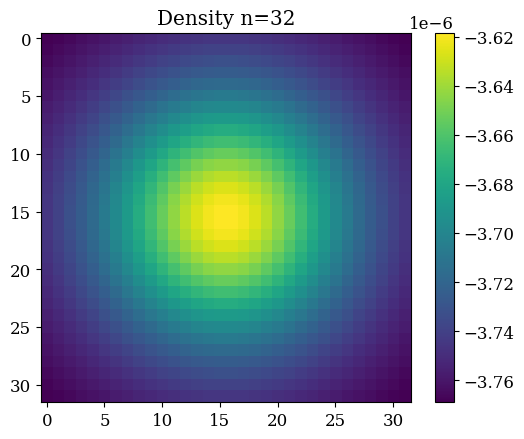

In [9]:
fig, ax = plt.subplots()
im=ax.imshow(b[0])
fig.colorbar(im, ax=ax)
ax.set_title(f'Density {n=}')
path="/local/home/mb280636/data/Dyablo/smoothers/pysco_tests"
fig.savefig(f"{path}/full_comparison/density_{source}.png", bbox_inches="tight", dpi=dpi)
plt.show()
plt.close(fig)
del fig, ax

In [10]:
r0 = residual(x0,b)
re0 = residual_error(x0,b)
print(re0, x0[n//2,n//2,n//2], b[n//2,n//2,n//2])

0.020999358966946602 0.0 0.0072537162


# Compute residual on each iteration for the following smoothers:
    Jacobi, Jacobi (weighted), Gauss-Seidel, GS (weighted/SOR), Chebyshev (1st kind), Lottes Chebyshev (4th kind)

In [11]:
# Jacobi
xj = x0.copy()
rj = np.empty(nsmooth+1)
rj[0] = re0
for i in range(nsmooth):
    jacobi(tmp, xj,b)
    tmp, xj = xj, tmp
    rj[i+1] = residual_error(xj,b)

In [12]:
# Jacobi Weighted
xjw = x0.copy()
rjw = np.empty(nsmooth+1)
rjw[0] = re0
w = np.float32(0.9)
for i in range(nsmooth):
    jacobi_w(tmp, xjw, b, w)
    tmp, xjw = xjw, tmp
    rjw[i+1] = residual_error(xjw,b)

In [13]:
# Gauss-Seidel
xg0 = x0.copy()
rg0 = np.empty(nsmooth+1)
f_relax0 = np.float32(1.)
rg0[0] = re0
for i in range(nsmooth):
    gauss_seidel(xg0,b, f_relax0)
    rg0[i+1] = residual_error(xg0,b)

In [14]:
# Gauss-Seidel with SOR
xg = x0.copy()
rg = np.empty(nsmooth+1)
f_relax = np.float32(1.25)
rg[0] = re0
for i in range(nsmooth):
    gauss_seidel(xg,b, f_relax)
    rg[i+1] = residual_error(xg,b)

In [15]:
# Standard 1st-kind Chebyshev
xc = x0.copy()
rc = np.empty(nsmooth+1)
rc[0] = re0
h = np.float32(1./x0.shape[0])
Dm1 = np.float32(-h*h/6.)
rr = r0.copy()
# --- eigenvalue estimates (3D Poisson) ---
ncells_1d = xc.shape[0]
h2 = np.float32(1.0 / ncells_1d**2)
lambda_max = np.float32(2.)
lambda_min = np.float32(0.1) * lambda_max
theta = np.float32(0.5) * (lambda_max + lambda_min)
delta = np.float32(0.5) * (lambda_max - lambda_min)
#----- RUn
alpha, beta = chebyshev_coeffs(nsmooth, theta, delta)
z = alpha[0]*Dm1*rr
for k in range(nsmooth):
    chebyshev_form1(xc, tmp, z, rr, alpha[k+1], beta[k+1])
    z, tmp = tmp, z
    rc[k+1] = residual_error(xc,b)

In [16]:
# Lottes Chebyshev of 4th kind
xcl = x0.copy()
rcl = np.empty(nsmooth+1)
rcl[0] = re0
h = np.float32(1./x0.shape[0])
Dm1 = np.float32(-h*h/6.)
# --- eigenvalue estimates (3D Poisson) ---
ncells_1d = xcl.shape[0]
h2 = np.float32(1.0 / ncells_1d**2)
lambda_max = np.float32(2.)
nu = np.float32(4/lambda_max)
#----- Run
alpha, beta = chebyshev_coeffs_lottes(nsmooth, nu)
rr = r0.copy()
z = alpha[0]*Dm1*rr
for k in range(nsmooth):
    chebyshev_form1(xcl, tmp, z, rr, alpha[k+1], beta[k+1])
    tmp, z = z, tmp
    rcl[k+1] = residual_error(xcl,b)

In [17]:
# Lottes Chebyshev of 4th kind Optimised
xclo = x0.copy()
rclo = np.empty(nsmooth+1)
rclo[0] = re0
h = np.float32(1./x0.shape[0])
Dm1 = np.float32(-h*h/6.)
# --- eigenvalue estimates (3D Poisson) ---
ncells_1d = xclo.shape[0]
h2 = np.float32(1.0 / ncells_1d**2)
lambda_max = np.float32(2.)
nu = np.float32(4/lambda_max)
#----- Run
alpha, beta = chebyshev_coeffs_lottes(nsmooth, nu)
gamma = gamma_tabular(nsmooth)
rr = r0.copy()
z = alpha[0]*Dm1*rr
for k in range(nsmooth):
    chebyshev_form1_opt(xclo, tmp, z, rr, alpha[k+1], beta[k+1], gamma[k])
    tmp, z = z, tmp
    rclo[k+1] = residual_error(xclo,b)

## Compute final residual for the pysco smoother utility

In [18]:
label_jacobi="Jacobi"
label_jacobi_w=f"Jacobi (w = {w:.2f})"
label_gs0="Gauss-Seidel"
label_gs=f"Gauss-Seidel (w = {f_relax:.2f})"
label_c="Chebyshev"
label_cl="Chebyshev Lottes"
label_clo="Chebyshev Lottes Opt"

## Plot residual per iteration for all smoothers

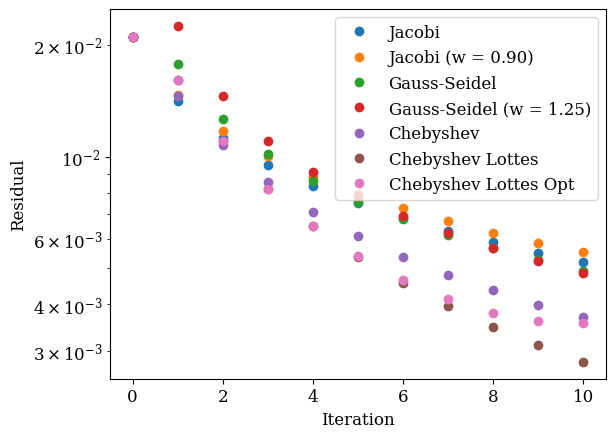

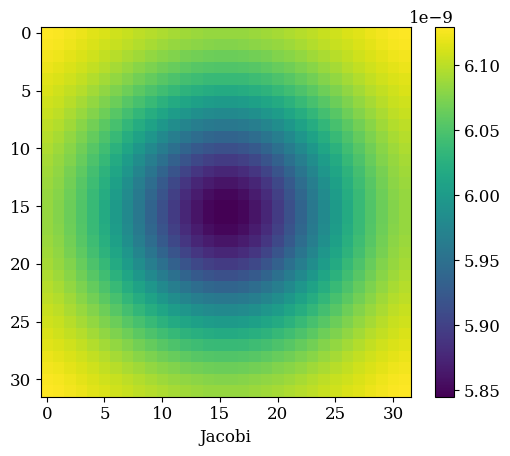

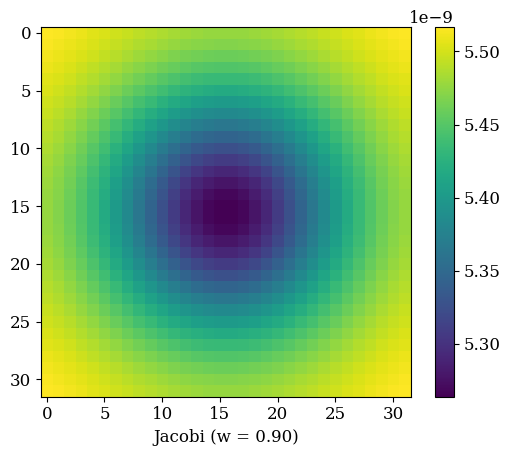

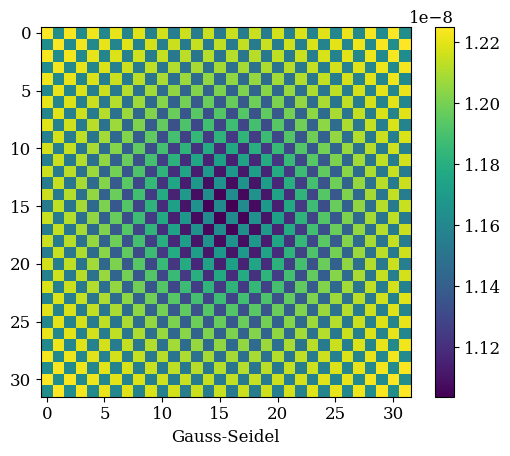

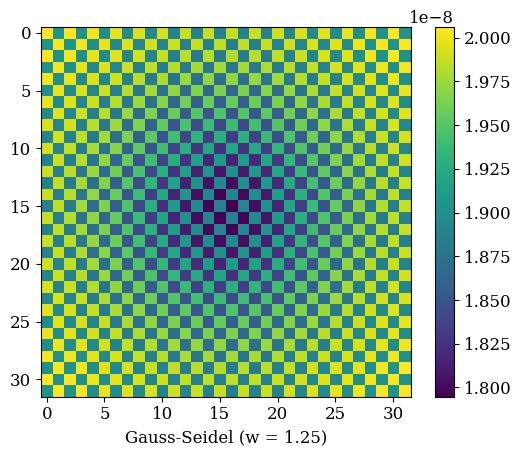

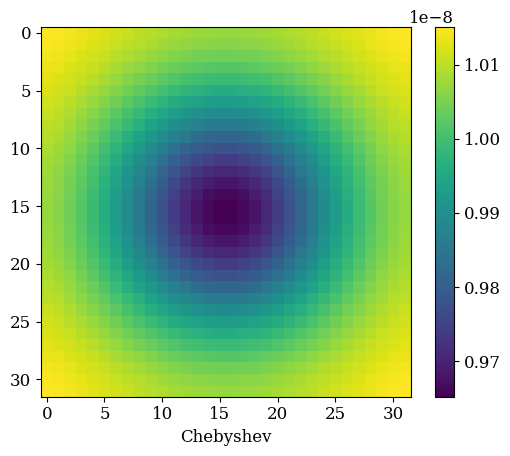

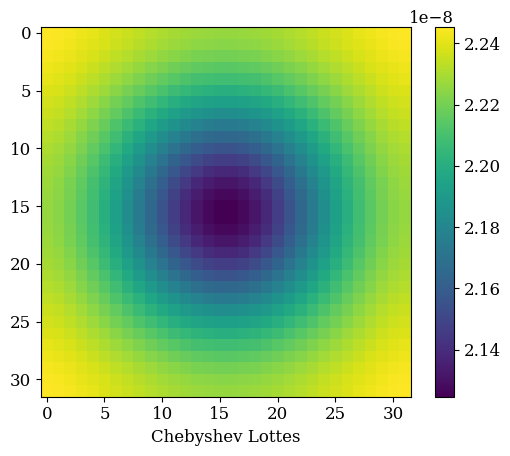

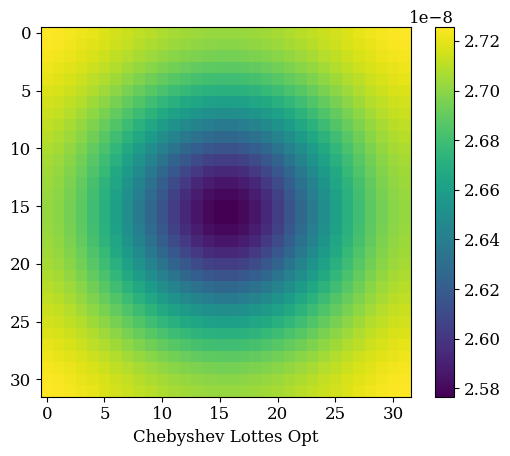

In [19]:
fig, ax = plt.subplots()
ax.semilogy(rj, "o", label=label_jacobi)
ax.semilogy(rjw, "o", label=label_jacobi_w)
ax.semilogy(rg0, "o", label=label_gs0)
ax.semilogy(rg, "o", label=label_gs)
ax.semilogy(rc, "o", label=label_c)
ax.semilogy(rcl, "o", label=label_cl)
ax.semilogy(rclo, "o", label=label_clo)
ax.set_ylabel("Residual")
ax.set_xlabel("Iteration")
ax.legend()
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xj[0])
plt.colorbar(im, ax=ax)
ax.set_xlabel(label_jacobi)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xjw[0])
plt.colorbar(im, ax=ax)
ax.set_xlabel(label_jacobi_w)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xg0[0])
plt.colorbar(im, ax=ax)
ax.set_xlabel(label_gs0)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xg[0])
plt.colorbar(im, ax=ax)
ax.set_xlabel(label_gs)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xc[0])
plt.colorbar(im, ax=ax)
ax.set_xlabel(label_c)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xcl[0])
plt.colorbar(im, ax=ax)
ax.set_xlabel(label_cl)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xclo[0])
plt.colorbar(im, ax=ax)
ax.set_xlabel(label_clo)
plt.show()
plt.close(fig)
del fig,ax


## Compute timings for smoothers

In [20]:
x_tmp = x0.copy()
rr = r0.copy()

In [21]:
tj = %timeit -o jacobi(tmp, x_tmp,b)
#tjs = %timeit -o smoothing_jacobi(x0,b,nsmooth)

18 μs ± 1.66 μs per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [22]:
tjw = %timeit -o jacobi_w(tmp, x_tmp,b, w)
#tjws = %timeit -o smoothing_jacobi_w(x0,b,nsmooth,w)

18.7 μs ± 48.6 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [23]:
tg0 = %timeit -o gauss_seidel(x_tmp,b, f_relax0)
#tg0s = %timeit -o smoothing_gs(x0,b,nsmooth, 1.0)

32.7 μs ± 78.8 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [24]:
tg = %timeit -o gauss_seidel(x_tmp,b, f_relax)
#tgs = %timeit -o smoothing_gs(x0,b,nsmooth, f_relax)

32.8 μs ± 49.7 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [25]:
tc = %timeit -o chebyshev_form1(x_tmp, tmp, z, rr, alpha[1], beta[1])
#tcs = %timeit -o smoothing_chebyshev1(x0,b,nsmooth, lambda_min, lambda_max)
#tcls = %timeit -o smoothing_chebyshev4(x0,b,nsmooth, lambda_max)

24 μs ± 527 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [26]:
tco = %timeit -o chebyshev_form1_opt(x_tmp, tmp, z, rr, alpha[1], beta[1], gamma[0])

24.2 μs ± 65.9 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [27]:
print(f"{tj.average=} {tjw.average=} {tg0.average=} {tg.average=} {tc.average=} {tco.average=}")

tj.average=1.801257431857266e-05 tjw.average=1.8659897791429624e-05 tg0.average=3.2686331071454335e-05 tg.average=3.2789582799991224e-05 tc.average=2.4024567171441698e-05 tco.average=2.4207737614298302e-05


## Plot residual as function of time for all smoothers

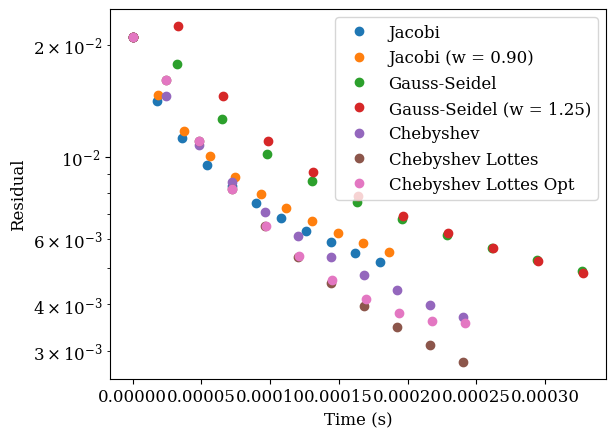

In [28]:
fig, ax = plt.subplots()
ax.semilogy(np.arange(nsmooth+1)*tj.average, rj, 'o', label=label_jacobi)
ax.semilogy(np.arange(nsmooth+1)*tjw.average, rjw, 'o', label=label_jacobi_w)
ax.semilogy(np.arange(nsmooth+1)*tg0.average, rg0, 'o', label=label_gs0)
ax.semilogy(np.arange(nsmooth+1)*tg.average, rg, 'o', label=label_gs)
ax.semilogy(np.arange(nsmooth+1)*tc.average, rc, 'o', label=label_c)
ax.semilogy(np.arange(nsmooth+1)*tc.average, rcl, 'o', label=label_cl)
ax.semilogy(np.arange(nsmooth+1)*tco.average, rclo, 'o', label=label_clo)
#plt.semilogy(tjs.best, rj[-1], 'v')
#plt.semilogy(tjws.best, rjw[-1], 'v')
#plt.semilogy(tg0s.best, rg0[-1], 'v')
#plt.semilogy(tgs.best, rg[-1], 'v')
#plt.semilogy(tcs.best, rc[-1], 'v')
#plt.semilogy(tcls.best, rcl[-1], 'v')
ax.set_ylabel('Residual')
ax.set_xlabel('Time (s)')
ax.legend()
plt.show()
plt.close(fig)
del fig,ax

# Define V-cycle iteration for all smoothers

In [29]:
param = {}
param["Npre"] = 2
param["Npost"] = 1
param["ncoarse"] = np.log2(n)
print(f"{param=}")

param={'Npre': 2, 'Npost': 1, 'ncoarse': np.float64(5.0)}


In [30]:
niter = 5
print(f"{residual_error(x0,b)=}")
rp_v = np.zeros(niter+1)
rj_v = np.zeros_like(rp_v)
rjw_v = np.zeros_like(rp_v)
rg0_v = np.zeros_like(rp_v)
rg_v = np.zeros_like(rp_v)
rc_v = np.zeros_like(rp_v)
rcl_v = np.zeros_like(rp_v)
rclo_v = np.zeros_like(rp_v)
rp_v[0] = rj_v[0] = rjw_v[0] = rg0_v[0] = rg_v[0] = rc_v[0] = rcl_v[0] = rclo_v[0] = re0
xp = x0.copy() 
xj = x0.copy() 
xjw = x0.copy() 
xg0 = x0.copy() 
xg = x0.copy() 
xc = x0.copy() 
xcl = x0.copy() 
xclo = x0.copy() 
r = rp_v.copy()
for i in range(niter):
    V_cycle(xp, b, param)
    V_cycle_jacobi(xj, b, param)
    V_cycle_jacobi_w(xjw, b, param, w)
    V_cycle_gs(xg0, b, param, f_relax0)
    V_cycle_gs(xg, b, param, f_relax)
    V_cycle_chebyshev1(xc, b, param, lambda_min, lambda_max)
    V_cycle_chebyshev4(xcl, b, param, lambda_max)
    V_cycle_chebyshev4_opt(xclo, b, param, lambda_max)
    rp_v[i+1] = residual_error(xp, b)
    rj_v[i+1] = residual_error(xj, b)
    rjw_v[i+1] = residual_error(xjw, b)
    rg0_v[i+1] = residual_error(xg0, b)
    rg_v[i+1] = residual_error(xg, b)
    rc_v[i+1] = residual_error(xc, b)
    rcl_v[i+1] = residual_error(xcl, b)    
    rclo_v[i+1] = residual_error(xclo, b)

residual_error(x0,b)=0.020999358966946602


## Plot residual for each V cycle iteration

In [31]:
rg_v_ref = rg_v.copy() # Use this as reference for best-case convergence, GS with w=1.25 with Npre=2, Npost=1

In [32]:
rp_v, rg_v

(array([2.09993590e-02, 1.35488342e-03, 2.39052570e-05, 8.92973844e-07,
        4.92840186e-08, 2.99068752e-08]),
 array([2.09993590e-02, 1.35488342e-03, 2.39052570e-05, 8.92973844e-07,
        4.92840186e-08, 2.99068752e-08]))

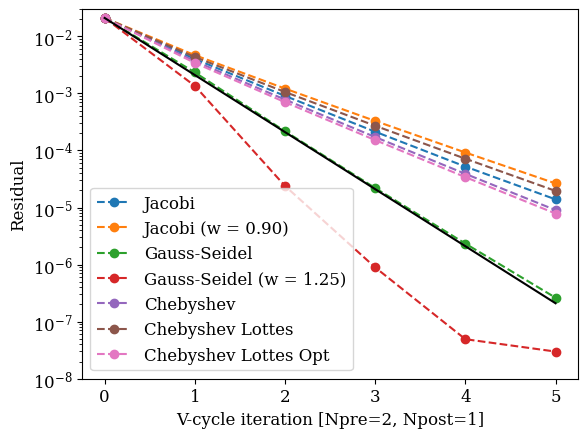

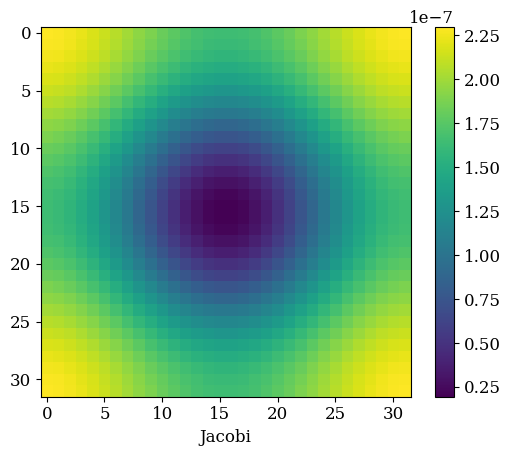

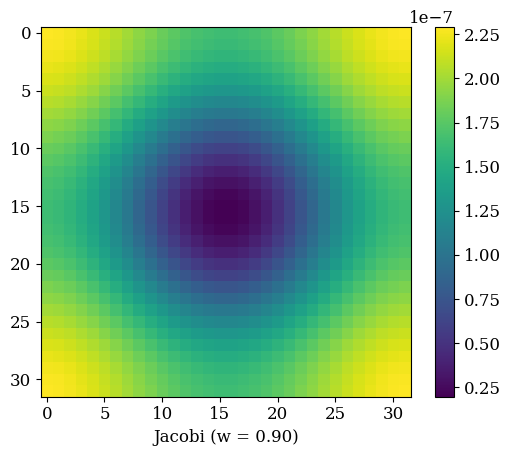

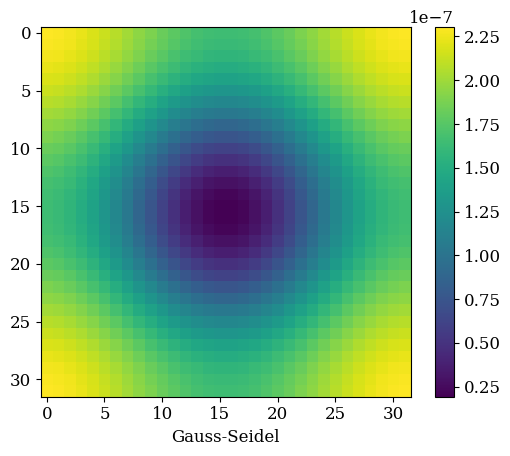

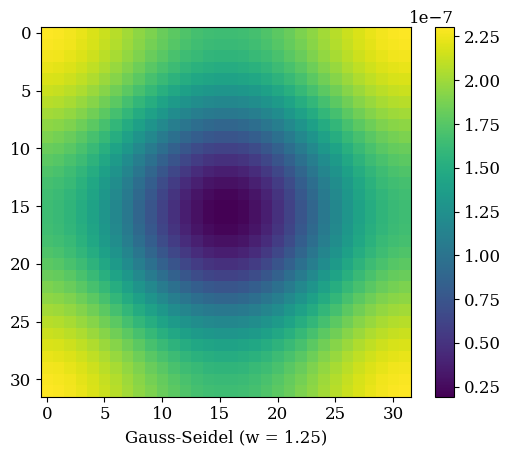

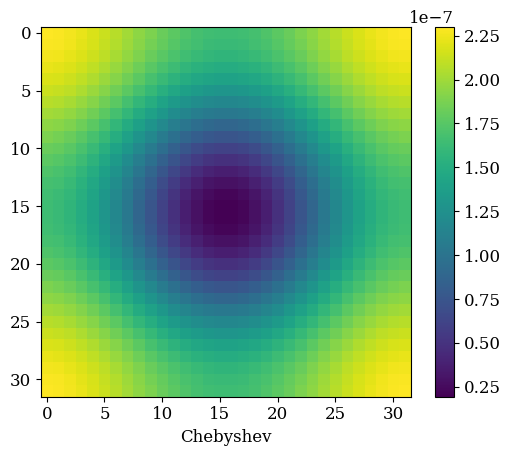

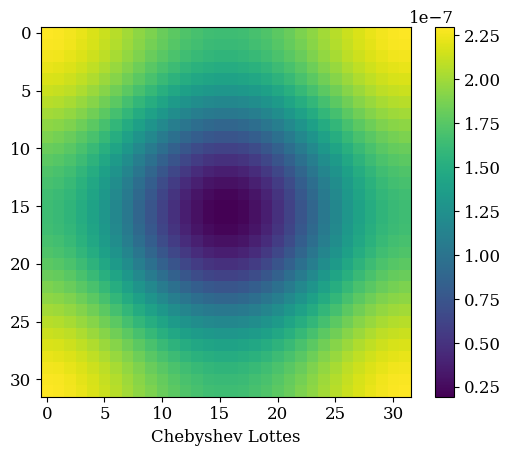

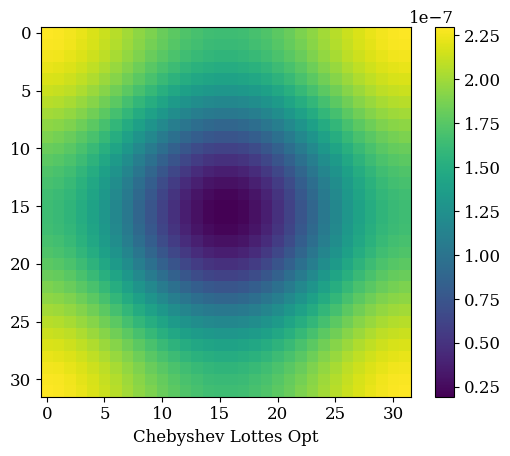

In [33]:
fig, ax = plt.subplots()
ax.semilogy(rj_v, "o", linestyle="--", label=label_jacobi)
ax.semilogy(rjw_v, "o", linestyle="--", label=label_jacobi_w)
ax.semilogy(rg0_v, "o", linestyle="--", label=label_gs0)
ax.semilogy(rg_v, "o", linestyle="--", label=label_gs)
ax.semilogy(rc_v, "o", linestyle="--", label=label_c)
ax.semilogy(rcl_v, "o", linestyle="--", label=label_cl)
ax.semilogy(rclo_v, "o", linestyle="--", label=label_clo)
#ax.semilogy(rp_v, '--', label="PySCo")
ax.semilogy(re0*0.1**np.arange(niter+1), "k")
ax.set_ylabel("Residual")
Npre = param["Npre"]
Npost = param["Npost"]
ax.set_xlabel(f"V-cycle iteration [{Npre=}, {Npost=}]")
ax.set_ylim(0.1**(niter+3), 3e-2)
ax.legend()
path="/local/home/mb280636/data/Dyablo/smoothers/pysco_tests"
#plt.savefig(f"{path}/residual_convergence_Vcycle_Npre{Npre}_Npost{Npost}.png", bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)
del fig,ax

#plt.figure(0)
#plt.imshow(xp[0])
#plt.colorbar()
#plt.xlabel("PySCo")
fig, ax = plt.subplots()
im=ax.imshow(xj[0])
fig.colorbar(im,ax=ax)
ax.set_xlabel(label_jacobi)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xjw[0])
fig.colorbar(im,ax=ax)
ax.set_xlabel(label_jacobi_w)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xg0[0])
fig.colorbar(im,ax=ax)
ax.set_xlabel(label_gs0)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xg[0])
fig.colorbar(im,ax=ax)
ax.set_xlabel(label_gs)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xc[0])
fig.colorbar(im,ax=ax)
ax.set_xlabel(label_c)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xcl[0])
fig.colorbar(im,ax=ax)
ax.set_xlabel(label_cl)
plt.show()
plt.close(fig)
del fig,ax

fig, ax = plt.subplots()
im=ax.imshow(xclo[0])
fig.colorbar(im,ax=ax)
ax.set_xlabel(label_clo)
plt.show()
plt.close(fig)
del fig,ax

# Fine-tuning parameters of smoothers

In [34]:
niter = 5 # Max number of V-cycles
nsmooth = 10 # Max number of smoothing interations for solver convergence
nsmooth_max = 4 # Maximum of Npre+Npost smoothing iterations for V cycles

In [35]:
npoints = 41
w_array = np.linspace(0.5, 1.5, npoints).astype(np.float32)
lambda_max_array = np.linspace(1., 3., npoints).astype(np.float32)
f_array = np.linspace(0., 0.4, npoints).astype(np.float32) # Used as lambda_min = f lambda_max
x = np.zeros_like(xp)
output_smooth = np.zeros((npoints, nsmooth+1)).astype(np.float32)
output = np.zeros((npoints, niter+1)).astype(np.float32)

if (len(w_array) != len(lambda_max_array)) or (len(w_array) != len(f_array)):
    raise ValueError(f"Check lengths {w_array.shape=} {lambda_max_array.shape=} {f_array.shape=}")
colors = pl.cm.coolwarm(np.linspace(0, 1, npoints))

## Jacobi

In [36]:
output_smooth.fill(0)
output_smooth[:,0] = re0
meta = {"w": w_array.tolist()}
header = json.dumps(meta)
for i, w in enumerate(w_array):
    x = x0.copy()
    for j in range(nsmooth):
        jacobi_w(tmp, x, b, w)
        tmp, x = x, tmp
        output_smooth[i,j+1] = residual_error(x,b)
    np.savetxt(f"{path}/jacobi_weight/residual_source_{source}_solver.dat", output_smooth.T, header=header,fmt="%.4e")

In [37]:
output.fill(0)
output[:,0] = re0
meta = {"w": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            resmin = re0
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            header = json.dumps(meta)
            for i, w in enumerate(w_array):
                x = x0.copy()
                for j in range(niter):
                    V_cycle_jacobi_w(x, b, param, w)
                    output[i,j+1] = residual_error(x,b)
                np.savetxt(f"{path}/jacobi_weight/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}.dat", output.T, header=header,fmt="%.4e")

## Gauss-Seidel

In [38]:
output_smooth.fill(0)
output_smooth[:,0] = re0
meta = {"w": w_array.tolist()}
header = json.dumps(meta)
for i, w in enumerate(w_array):
    x = x0.copy() 
    for j in range(nsmooth):
        gauss_seidel(x, b, w)
        output_smooth[i,j+1] = residual_error(x,b)
    np.savetxt(f"{path}/gauss_seidel/residual_source_{source}_solver.dat", output_smooth.T, header=header,fmt="%.4e")

In [39]:
output.fill(0)
output[:,0] = re0
meta = {"w": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            header = json.dumps(meta)
            for i, w in enumerate(w_array):
                x = x0.copy()
                for j in range(niter):
                    V_cycle_gs(x, b, param, w)
                    output[i,j+1] = residual_error(x,b)
                np.savetxt(f"{path}/gauss_seidel/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}.dat", output.T, header=header,fmt="%.4e")

## Chebyshev

In [40]:
h = np.float32(1./x0.shape[0])
h2 = np.float32(h*h)
Dm1 = np.float32(-h*h/6.)

## Chebyshev 1st-kind

In [41]:
output_smooth.fill(0)
output_smooth[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for f in f_array:
    meta["f"] = float(f)
    header = json.dumps(meta)
    for i, lambda_max in enumerate(lambda_max_array):
        lambda_min = f * lambda_max
        theta = np.float32(0.5) * (lambda_max + lambda_min)
        delta = np.float32(0.5) * (lambda_max - lambda_min)
        x = x0.copy() 
        rr = r0.copy()
        alpha, beta = chebyshev_coeffs(nsmooth, theta, delta)
        z = alpha[0]*Dm1*rr
        for j in range(nsmooth):
            chebyshev_form1(x, tmp, z, rr, alpha[j+1], beta[j+1])
            z, tmp = tmp, z
            output_smooth[i,j+1] = residual_error(x,b)
        np.savetxt(f"{path}/chebyshev1/residual_source_{source}_solver_f_{f:.3f}.dat", output_smooth.T, header=header,fmt="%.4e")

In [42]:
output_smooth.fill(0)
output_smooth[:,0] = re0
meta = {"f": f_array.tolist()}
header = json.dumps(meta)
for lambda_max in lambda_max_array:
    for i, f in enumerate(f_array):
        lambda_min = f * lambda_max
        theta = np.float32(0.5) * (lambda_max + lambda_min)
        delta = np.float32(0.5) * (lambda_max - lambda_min)
        x = x0.copy() 
        rr = r0.copy()
        alpha, beta = chebyshev_coeffs(nsmooth, theta, delta)
        z = alpha[0]*Dm1*rr
        for j in range(nsmooth):
            chebyshev_form1(x, tmp, z, rr, alpha[j+1], beta[j+1])
            z, tmp = tmp, z
            output_smooth[i,j+1] = residual_error(x,b)
        np.savetxt(f"{path}/chebyshev1/residual_source_{source}_solver_lambda_max_{lambda_max:.3f}.dat", output_smooth.T, header=header,fmt="%.4e")

In [43]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for f in f_array:
                meta["f"] = float(f)
                header = json.dumps(meta)
                for i, lambda_max in enumerate(lambda_max_array):
                    lambda_min = f * lambda_max
                    theta = np.float32(0.5) * (lambda_max + lambda_min)
                    delta = np.float32(0.5) * (lambda_max - lambda_min)
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev1(x, b, param, lambda_min, lambda_max)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev1/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_f_{f:.3f}.dat", output.T, header=header,fmt="%.4e")

In [44]:
output.fill(0)
output[:,0] = re0
meta = {"f": f_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for lambda_max in lambda_max_array:
                meta["lambda_max"] = float(lambda_max)
                header = json.dumps(meta)
                for i, f in enumerate(f_array):
                    lambda_min = f * lambda_max
                    theta = np.float32(0.5) * (lambda_max + lambda_min)
                    delta = np.float32(0.5) * (lambda_max - lambda_min)
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev1(x, b, param, lambda_min, lambda_max)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev1/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_lambda_max_{lambda_max:.3f}.dat", output.T, header=header,fmt="%.4e")

## Lottes Chebyshev 4th kind

In [45]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
header = json.dumps(meta)
for i, lambda_max in enumerate(lambda_max_array):
    x = x0.copy() 
    rr = r0.copy()
    nu = np.float32(4/lambda_max)
    alpha, beta = chebyshev_coeffs_lottes(nsmooth, nu)
    z = alpha[0]*Dm1*rr
    for j in range(nsmooth):
        chebyshev_form1(x, tmp, z, rr, alpha[j+1], beta[j+1])
        z, tmp = tmp, z
        output_smooth[i,j+1] = residual_error(x,b)
    np.savetxt(f"{path}/chebyshev4/residual_source_{source}_solver.dat", output_smooth.T, header=header,fmt="%.4e")

In [46]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            header = json.dumps(meta)
            for i, lambda_max in enumerate(lambda_max_array):
                x = x0.copy() 
                for j in range(niter):
                    V_cycle_chebyshev4(x, b, param, lambda_max)
                    output[i,j+1] = residual_error(x,b)
                np.savetxt(f"{path}/chebyshev4/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}.dat", output.T, header=header,fmt="%.4e")

## Lottes Chebyshev 4th kind Optimised

In [47]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
header = json.dumps(meta)
for i, lambda_max in enumerate(lambda_max_array):
    x = x0.copy() 
    rr = r0.copy()
    nu = np.float32(4/lambda_max)
    alpha, beta = chebyshev_coeffs_lottes(nsmooth, nu)
    gamma = gamma_tabular(nsmooth)
    z = alpha[0]*Dm1*rr
    for j in range(nsmooth):
        chebyshev_form1_opt(x, tmp, z, rr, alpha[j+1], beta[j+1], gamma[j])
        z, tmp = tmp, z
        output_smooth[i,j+1] = residual_error(x,b)
    np.savetxt(f"{path}/chebyshev4_opt/residual_source_{source}_solver.dat", output_smooth.T, header=header,fmt="%.4e")

In [48]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            header = json.dumps(meta)
            for i, lambda_max in enumerate(lambda_max_array):
                x = x0.copy() 
                for j in range(niter):
                    V_cycle_chebyshev4_opt(x, b, param, lambda_max)
                    output[i,j+1] = residual_error(x,b)
                np.savetxt(f"{path}/chebyshev4_opt/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}.dat", output.T, header=header,fmt="%.4e")

# Multigrid with mixed smoothers

## Jacobi - Jacobi (different weights)

In [49]:
output.fill(0)
output[:,0] = re0
meta = {"w2": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w1 in w_array:
                meta["w1"] = float(w1)
                header = json.dumps(meta)
                for i, w2 in enumerate(w_array):
                    x = x0.copy()
                    for j in range(niter):
                        V_cycle_jacobi_w1w2(x, b, param, w1,w2)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/jacobi-jacobi/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w1_{w1:.3f}.dat", output.T, header=header,fmt="%.4e")

In [50]:
output.fill(0)
output[:,0] = re0
meta = {"w1": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w2 in w_array:
                meta["w2"] = float(w2)
                header = json.dumps(meta)
                for i, w1 in enumerate(w_array):
                    x = x0.copy()
                    for j in range(niter):
                        V_cycle_jacobi_w1w2(x, b, param, w1,w2)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/jacobi-jacobi/jacobi_residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w2_{w2:.3f}.dat", output.T, header=header,fmt="%.4e")

## Gauss-Seidel - Gauss-Seidel (different weights)

In [51]:
output.fill(0)
output[:,0] = re0
meta = {"w2": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w1 in w_array:
                meta["w1"] = float(w1)
                header = json.dumps(meta)
                for i, w2 in enumerate(w_array):
                    x = x0.copy()
                    for j in range(niter):
                        V_cycle_gs_w1w2(x, b, param, w1,w2)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/gs-gs/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w1_{w1:.3f}.dat", output.T, header=header,fmt="%.4e")

In [52]:
output.fill(0)
output[:,0] = re0
meta = {"w1": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w2 in w_array:
                meta["w2"] = float(w2)
                header = json.dumps(meta)
                for i, w1 in enumerate(w_array):
                    x = x0.copy()
                    for j in range(niter):
                        V_cycle_gs_w1w2(x, b, param, w1,w2)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/gs-gs/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w2_{w2:.3f}.dat", output.T, header=header,fmt="%.4e")

## Jacobi - Gauss-Seidel

In [53]:
output.fill(0)
output[:,0] = re0
meta = {"w2": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w1 in w_array:
                meta["w1"] = float(w1)
                header = json.dumps(meta)
                for i, w2 in enumerate(w_array):
                    x = x0.copy()
                    for j in range(niter):
                        V_cycle_jacobi_gs(x, b, param, w1,w2)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/jacobi-gs/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w1_{w1:.3f}.dat", output.T, header=header,fmt="%.4e")

## (Gauss-Seidel - Jacobi)

## Chebyshev 1st - Gauss-Seidel

In [54]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in prange(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for f in f_array:
                meta["f"] = float(f)
                for w in w_array:
                    meta["w"] = float(w)
                    header = json.dumps(meta)
                    for i, lambda_max in enumerate(lambda_max_array):
                        lambda_min = f*lambda_max
                        x = x0.copy() 
                        for j in range(niter):
                            V_cycle_chebyshev1_gs(x, b, param, lambda_min, lambda_max, w)
                            output[i,j+1] = residual_error(x,b)
                        np.savetxt(f"{path}/chebyshev1-gs/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_f_{f:.3f}_w_{w:.3f}.dat", output.T, header=header,fmt="%.4e")

## Chebyshev 4th - Gauss-Seidel

In [55]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w in w_array:
                meta["w"] = float(w)
                header = json.dumps(meta)
                for i, lambda_max in enumerate(lambda_max_array):
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev4_gs(x, b, param, lambda_max, w)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev4-gs/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w_{w:.3f}.dat", output.T, header=header,fmt="%.4e")

In [56]:
output.fill(0)
output[:,0] = re0
meta = {"w": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for lambda_max in lambda_max_array:
                meta["lambda_max"] = float(lambda_max)
                header = json.dumps(meta)
                for i, w in enumerate(w_array):
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev4_gs(x, b, param, lambda_max, w)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev4-gs/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_lambda_max_{lambda_max:.3f}.dat", output.T, header=header,fmt="%.4e")

## Chebyshev 4th - Gauss-Seidel

In [57]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w in w_array:
                meta["w"] = float(w)
                header = json.dumps(meta)
                for i, lambda_max in enumerate(lambda_max_array):
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev4_opt_gs(x, b, param, lambda_max, w)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev4_opt-gs/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w_{w:.3f}.dat", output.T, header=header,fmt="%.4e")

In [58]:
output.fill(0)
output[:,0] = re0
meta = {"w": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for lambda_max in lambda_max_array:
                meta["lambda_max"] = float(lambda_max)
                header = json.dumps(meta)
                for i, w in enumerate(w_array):
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev4_opt_gs(x, b, param, lambda_max, w)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev4_opt-gs/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_lambda_max_{lambda_max:.3f}.dat", output.T, header=header,fmt="%.4e")

## Chebyshev 1st - Jacobi

In [59]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in prange(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for f in f_array:
                meta["f"] = float(f)
                for w in w_array:
                    meta["w"] = float(w)
                    header = json.dumps(meta)
                    for i, lambda_max in enumerate(lambda_max_array):
                        lambda_min = f*lambda_max
                        x = x0.copy() 
                        for j in range(niter):
                            V_cycle_chebyshev1_jacobi(x, b, param, lambda_min, lambda_max, w)
                            output[i,j+1] = residual_error(x,b)
                        np.savetxt(f"{path}/chebyshev1-jacobi/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_f_{f:.3f}_w_{w:.3f}.dat", output.T, header=header,fmt="%.4e")

## Chebyshev 4th - Jacobi

In [60]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w in w_array:
                meta["w"] = float(w)
                header = json.dumps(meta)
                for i, lambda_max in enumerate(lambda_max_array):
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev4_jacobi(x, b, param, lambda_max, w)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev4-jacobi/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w_{w:.3f}.dat", output.T, header=header,fmt="%.4e")

In [61]:
output.fill(0)
output[:,0] = re0
meta = {"w": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for lambda_max in lambda_max_array:
                meta["lambda_max"] = float(lambda_max)
                header = json.dumps(meta)
                for i, w in enumerate(w_array):
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev4_jacobi(x, b, param, lambda_max, w)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev4-jacobi/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_lambda_max_{lambda_max:.3f}.dat", output.T, header=header,fmt="%.4e")

## Chebyshev 4th Optimised - Jacobi

In [62]:
output.fill(0)
output[:,0] = re0
meta = {"lambda_max": lambda_max_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for w in w_array:
                meta["w"] = float(w)
                header = json.dumps(meta)
                for i, lambda_max in enumerate(lambda_max_array):
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev4_opt_jacobi(x, b, param, lambda_max, w)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev4_opt-jacobi/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_w_{w:.3f}.dat", output.T, header=header,fmt="%.4e")

In [63]:
output.fill(0)
output[:,0] = re0
meta = {"w_array": w_array.tolist()}
for Npre in range(nsmooth_max+1):
    for Npost in range(nsmooth_max+1):
        if Npre+Npost <= nsmooth_max:
            meta["Npre"] = Npre
            meta["Npost"] = Npost
            param["Npre"] = Npre
            param["Npost"] = Npost
            for lambda_max in lambda_max_array:
                meta["lambda_max"] = float(lambda_max)
                header = json.dumps(meta)
                for i, w in enumerate(w_array):
                    x = x0.copy() 
                    for j in range(niter):
                        V_cycle_chebyshev4_opt_jacobi(x, b, param, lambda_max, w)
                        output[i,j+1] = residual_error(x,b)
                    np.savetxt(f"{path}/chebyshev4_opt-jacobi/residual_source_{source}_Vcycle_Npre{Npre}_Npost{Npost}_lambda_max_{lambda_max:.3f}.dat", output.T, header=header,fmt="%.4e")